<a href="https://colab.research.google.com/github/doa-2026/machine-learning/blob/main/Exam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 #Summary

 This project want to bulid and create a machine learning models to predict whether or not paitent has diabetes , and then choose the best model accuording to evaluation metrics .

Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path="/content/drive/MyDrive/Belt2_B_diabetes_v2_final.csv"
import pandas as pd
df=pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0
3,6,111.0,64.0,39.0,NaN,0.26,obese_1,18 - 44,F,0
4,3,106.0,72.0,NaN,NaN,0_207,overweight,18 - 44,F,0


In [ ]:
#summary state
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,Outcome
count,642.00,638.00,616.00,455.00,331.00,642.00
mean,5.45,124.04,72.40,29.48,159.00,0.42
std,39.46,30.76,12.31,10.53,117.26,0.49
min,0.00,56.00,24.00,7.00,14.00,0.00
25%,1.00,100.00,64.00,22.00,82.50,0.00
50%,3.00,121.00,72.00,30.00,130.00,0.00
75%,6.00,144.00,80.00,36.50,192.50,1.00
max,1000.00,199.00,114.00,99.00,846.00,1.00


In [ ]:
#ckeck for impossible values in numerical data
num_col=df.select_dtypes("number").columns
for i in num_col:
  print(i)
  print (df[i].value_counts())
  print("\n")


Pregnancies
Pregnancies
1       109
0        95
2        87
3        60
4        55
5        44
7        41
6        41
8        33
9        25
10       21
11       10
13        9
12        8
14        2
1000      1
15        1
Name: count, dtype: int64


Glucose
Glucose
99.0     15
125.0    13
129.0    13
106.0    12
124.0    11
         ..
169.0     1
160.0     1
182.0     1
172.0     1
186.0     1
Name: count, Length: 131, dtype: int64


BloodPressure
BloodPressure
70.0     52
74.0     42
64.0     38
78.0     38
68.0     37
76.0     35
72.0     34
62.0     32
80.0     31
60.0     30
82.0     28
66.0     25
84.0     21
88.0     20
58.0     19
90.0     19
86.0     18
56.0     10
52.0      9
50.0      9
75.0      8
54.0      8
94.0      5
85.0      4
44.0      4
96.0      4
92.0      4
110.0     3
48.0      3
100.0     3
98.0      3
65.0      3
30.0      2
46.0      2
108.0     2
40.0      2
106.0     2
104.0     2
55.0      1
61.0      1
24.0      1
102.0     1
114.0     1
Name: count

In [ ]:
#dealing  with value 1000 this is not acceptable in pregenancies column and replace it with mean value
df["Pregnancies"]=df["Pregnancies"].replace(1000,df["Pregnancies"].mean())
df["Pregnancies"].describe().round(3)


,Pregnancies
count,642.000
mean,3.904
std,3.408
min,0.000
25%,1.000
50%,3.000
75%,6.000
max,15.000


In [ ]:
#99 value in skinthickness column is very high ,, replace it with mean value
df["SkinThickness"]=df["SkinThickness"].replace(99,df["SkinThickness"].mean())
df["SkinThickness"].describe()

,SkinThickness
count,455.000000
mean,29.330733
std,10.007977
min,7.000000
25%,22.000000
50%,30.000000
75%,36.000000
max,63.000000


In [ ]:
#in blood pressure, 24 , 40 , 30 , 44  this value is not acceptable
df["BloodPressure"]=df["BloodPressure"].replace([24,40,44,30],df["BloodPressure"].mean())
df["BloodPressure"].round(3).value_counts()

,count
BloodPressure,
70.000,52
74.000,42
78.000,38
64.000,38
68.000,37
76.000,35
72.000,34
62.000,32
80.000,31


In [ ]:
#check datatypes for columns
df.dtypes

,0
Pregnancies,float64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
DiabetesPedigreeFunction,object
WeightGroup,object
AgeGroup,object
Gender,object
Outcome,int64


In [ ]:
df.round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4.0,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2.0,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6.0,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0
3,6.0,111.0,64.0,39.0,NaN,0.26,obese_1,18 - 44,F,0
4,3.0,106.0,72.0,NaN,NaN,0_207,overweight,18 - 44,F,0
...,...,...,...,...,...,...,...,...,...,...
637,5.0,144.0,82.0,26.0,285.0,0.452,obese_1,45 - 64,F,1
638,4.0,171.0,72.0,NaN,NaN,0.479,obsese_3,18 - 44,F,1
639,8.0,176.0,90.0,34.0,300.0,0.467,obese_1,45 - 64,F,1
640,0.0,104.0,64.0,37.0,64.0,0.51,obese_1,18 - 44,M,1


Prepare and clean data

In [ ]:
#check value count for categorial columns
obj=df.select_dtypes('object').columns
for i in obj:
  print(i)
  print(df[i].value_counts())
  print ('\n')

DiabetesPedigreeFunction
DiabetesPedigreeFunction
0.254                  5
0.19699999999999998    4
0.349                  4
0.23800000000000002    4
0.258                  4
                      ..
0.63                   1
0_605                  1
0_34700000000000003    1
0.341                  1
0.612                  1
Name: count, Length: 470, dtype: int64


WeightGroup
WeightGroup
obese_1           196
overweight        146
obese_2           126
obsese_3           87
healthy weight     75
MISSING             8
underweight         4
Name: count, dtype: int64


AgeGroup
AgeGroup
18 - 44    528
45 - 64    103
>65          8
<65          3
Name: count, dtype: int64


Gender
Gender
F    565
M     60
m     17
Name: count, dtype: int64




In [ ]:
#deal with inconsistent value in Gender Column
df["Gender"]=df["Gender"].replace({"m":"M"})
df["Gender"].value_counts()

,count
Gender,
F,565
M,77


In [ ]:
# DiabetesPedigreeFunction column contains inconsistent "_" insted of "." and then change the it's type to float
df["DiabetesPedigreeFunction"]=df["DiabetesPedigreeFunction"].str.replace("_",".")
df["DiabetesPedigreeFunction"].value_counts()
df["DiabetesPedigreeFunction"]=df["DiabetesPedigreeFunction"].astype(float)
df.dtypes

,0
Pregnancies,float64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
DiabetesPedigreeFunction,float64
WeightGroup,object
AgeGroup,object
Gender,object
Outcome,int64


In [ ]:
df["DiabetesPedigreeFunction"].round(3).value_counts()
#rounds each value to 3 decimal places

,count
DiabetesPedigreeFunction,
0.261,5
0.254,5
0.258,4
0.284,4
0.197,4
...,...
1.893,1
0.759,1
0.431,1


In [ ]:
#drop duplicated row
df.duplicated().sum()
df[df.duplicated(keep=False)]
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
#show the missing value
df.isna().sum()

,0
Pregnancies,0
Glucose,4
BloodPressure,26
SkinThickness,185
Insulin,309
DiabetesPedigreeFunction,0
WeightGroup,0
AgeGroup,0
Gender,0
Outcome,0


Import packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler ,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn import set_config
set_config(transform_output="pandas")



In [ ]:
#Perform a validation split
X=df.drop(columns="Outcome")
y=df["Outcome"]
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
#its binary classification

In [ ]:
#handle with missing value using simpleimputer
num_col= X_train.select_dtypes("number").columns
cat_col= X_train.select_dtypes("object").columns

imputer_num=SimpleImputer(strategy="mean")
imputer_cat=SimpleImputer(strategy="most_frequent")
#because all missing value in numerical columns
imputer_num.fit(X_train[num_col])

X_train_num_imputer=imputer_num.transform(X_train[num_col])
X_test_num_imputer=imputer_num.transform(X_test[num_col])

#using strategy "mean" fill the missing value in numerical columns with mean average of column
#before making imputer you should make split data to triain and test to avoid data leakage

In [ ]:
#ckeck again
X_train_num_imputer.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
DiabetesPedigreeFunction,0


Explore the data

[Text(0.5, 1.0, 'Outcome by AgeGroup'),
 Text(0.5, 0, 'AgeGroup'),
 Text(0, 0.5, 'Outcome')]

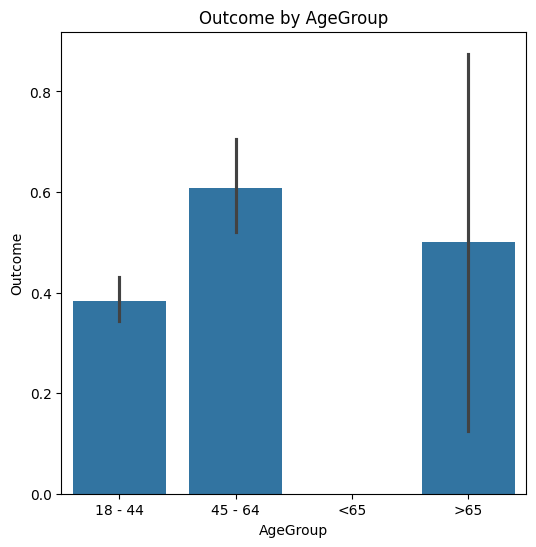

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))
ax=sns.barplot(y="Outcome",x="AgeGroup",data=df)
ax.set(title="Outcome by AgeGroup",xlabel="AgeGroup",ylabel="Outcome")
#this plot show us the relationship between AgeGroup pepole & determine if patient or not
# if age between 18-44 the average of patients  is almost .4 if the age is between 45-64 the avarge is increase to .6
#also if the age >65 the average of patient pepole about .5 but the value various (the error bar is large )

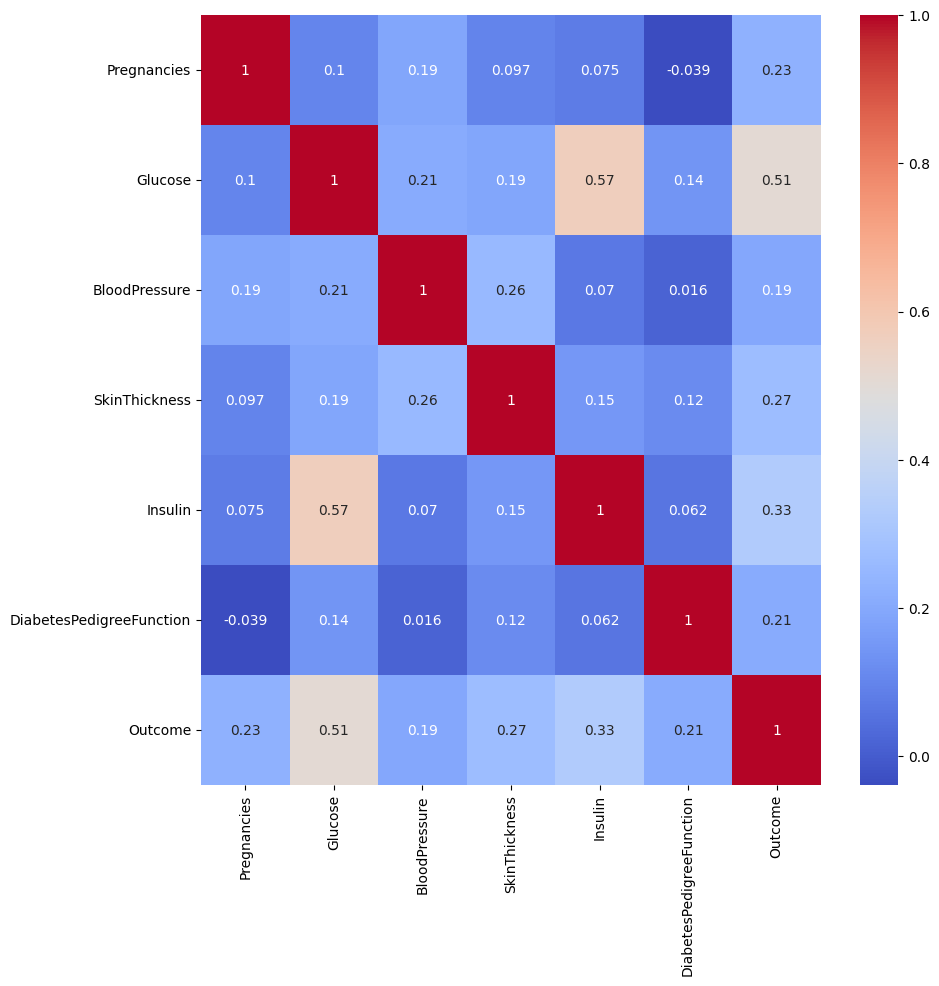

In [ ]:
corr=df.corr(numeric_only=True)
fig,ax= plt.subplots(figsize=(10,10))
ax=sns.heatmap(corr,annot=True,cmap="coolwarm")
#the highest relationship between outcome and Glucose .51 and this is logical value but not strong positive
#this plot shows the relation betweem Glucose and insulin about .57 is postive but also not strong

[Text(0.5, 1.0, 'Glucose and Insulin'),
 Text(0.5, 0, 'Glucose'),
 Text(0, 0.5, 'Insulin')]

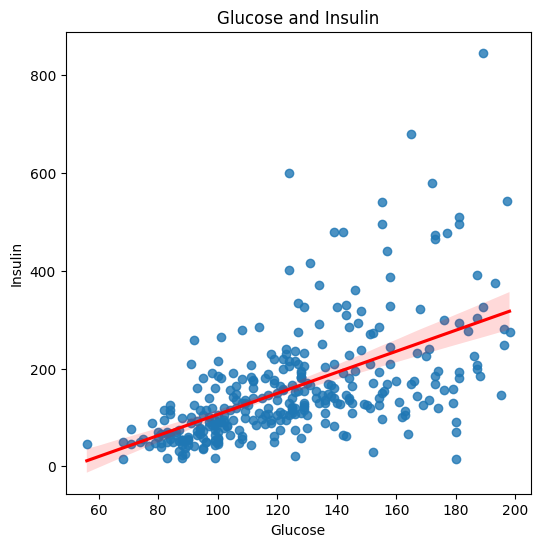

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))
line_kws=dict(color="red")
ax=sns.regplot(data=df,x="Glucose",y="Insulin",line_kws=line_kws)
ax.set(title="Glucose and Insulin",xlabel="Glucose",ylabel="Insulin")
#this plot shows increasing slop between Glucose and insulin ,, positive correlation
#when increase Glucose the insluin increased
#there is some outliear points above 300 in insulin


[Text(0.5, 1.0, 'DiabetesPedigreeFunction'),
 Text(0.5, 0, 'DiabetesPedigreeFunction'),
 Text(0, 0.5, 'count')]

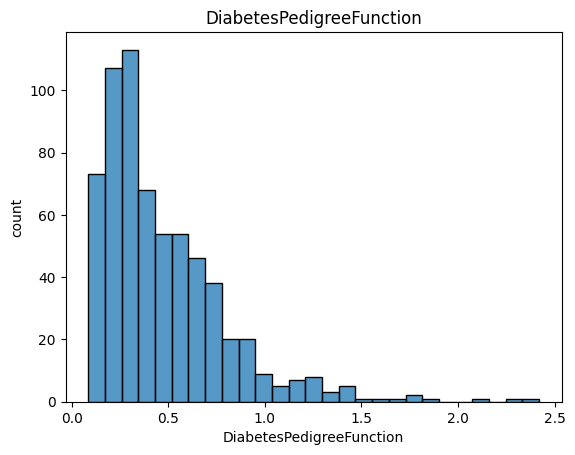

In [ ]:
ax=sns.histplot(data=df,x="DiabetesPedigreeFunction")
ax.set(title="DiabetesPedigreeFunction",xlabel="DiabetesPedigreeFunction",ylabel="count")
#the DiabetesPedigreeFunction (estimate how likely a person is to develop diabetes based on their family history) the highest counts of peolpe
# when the value of DiabetesPedigreeFunction is .3 then the counts of people  decresing  if the value of functio between (.5-2.5)

prepare data for modeling

In [ ]:
#preproccessing pipline
ordinal=["AgeGroup"]
order=['18 - 44','45 - 64',"<65",">65"]
num_col=X_train.select_dtypes("number").columns
cat_col=X_train.select_dtypes("object").drop(columns=ordinal).columns
#numerical columns

num_imp=SimpleImputer(strategy="mean")
scale=StandardScaler()
num_pip=make_pipeline(num_imp,scale)
num_tap=("number", num_pip , num_col)

#catagorical columns
cat_imp=SimpleImputer(strategy="constant",fill_value="missing")
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
cat_pip=make_pipeline(cat_imp,encoder)
cat_tap=("cat",cat_pip,cat_col)

#ordinal column
ordinal_imp=SimpleImputer(strategy="constant",fill_value="missing")
ordinal_encoder=OrdinalEncoder(categories=[order])
scale=StandardScaler()
ordinal_pip=make_pipeline(ordinal_imp,ordinal_encoder,scale)

ordinal_tap=("ordinal",ordinal_pip,ordinal)


# Colunmn Transformer
preprocessor=ColumnTransformer([num_tap,cat_tap,ordinal_tap],verbose_feature_names_out=False)
preprocessor.fit(X_train)



ColumnTransformer(transformers=[('number',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('one...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['WeightGroup', 'Gender'], dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['18 '
                                                                              '- '
                                                                              '44',
                                                                              '45 '
                                                                              '- '
                                                                              '64',
                                                                              '<65',
                                                                              '>65']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['AgeGroup'])],
                  verbose_feature_names_out=False)

In [ ]:
X_train_pre=preprocessor.transform(X_train)
X_test_pre=preprocessor.transform(X_test)
#transform training and testing data
X_train_pre.head(10)
#

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup_MISSING,WeightGroup_healthy weight,WeightGroup_obese_1,WeightGroup_obese_2,WeightGroup_obsese_3,WeightGroup_overweight,WeightGroup_underweight,Gender_F,Gender_M,AgeGroup
305,-1.173216,-1.031757,2.362072,1.112192e+00,-1.072740,1.650378,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.424599
546,-0.290287,-0.119851,-1.850050,4.118460e-16,0.000000,-1.051569,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.424599
515,-0.584597,0.987464,0.080506,-1.438144e+00,-0.777729,-0.126742,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.424599
357,-0.584597,-1.129461,0.607021,-1.785917e+00,-1.281706,-0.682847,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.424599
588,0.886951,1.410849,1.309041,1.459965e+00,1.988000,0.943157,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.424599
375,1.181261,-0.543235,-0.270505,4.118460e-16,0.000000,1.450905,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.424599
83,-0.878906,-0.901484,-0.446010,-9.744463e-01,0.000000,1.874029,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.424599
383,-0.878906,1.573689,0.080506,4.118460e-16,0.000000,-1.169439,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.424599
329,0.004022,0.205830,-0.446010,-9.744463e-01,0.082720,-0.951833,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.424599
578,-0.290287,-0.412963,0.080506,6.887269e-02,0.000000,-0.840007,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.424599


I used ordinal Encoder in AgeGroup because it's ordinal value , it convert each category to number with order 0,1,2

but another categorical features used one hot encoder that convert each category to number of columns which set the value with new columns to 1 if that row correspand to this category and 0 for another ones

Create Models

In [ ]:
rt=RandomForestClassifier(random_state=42)
rt_pip=make_pipeline(preprocessor,rt)
rt_pip.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=...
                                                  Index(['WeightGroup', 'Gender'], dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '<65',
                                                                                               '>65']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AgeGroup'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

I want to use Random Forest model its apperiate for unbalnced classfication and better than baggeging and dision tree
it contain many tree with random selection features  and random samples in each splits.

In [ ]:
#Evaluate Function
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict



----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       1.00      1.00      1.00       219

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



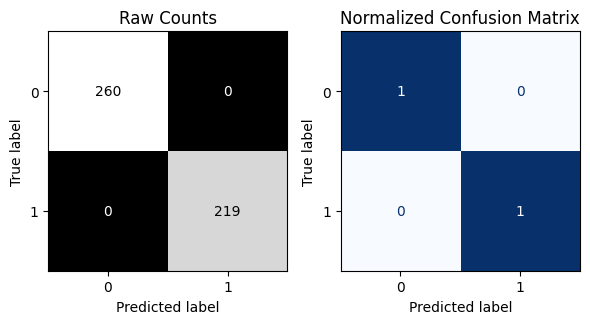


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       111
           1       0.55      0.73      0.63        49

    accuracy                           0.73       160
   macro avg       0.70      0.73      0.71       160
weighted avg       0.76      0.73      0.74       160



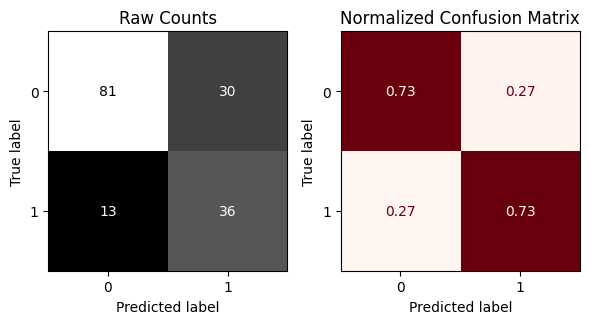

In [ ]:
#evaluate the default random forest
evaluate_classification(rt_pip,X_train,y_train,X_test,y_test)

In [ ]:
#tunning the RF model
rt_pip.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('number',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='missing',
                                                                   strategy='constant')),
                                                    ('one...
                                                     OneHotEncoder(handle_unknown='ig

In [ ]:
#Instaniate Grid search anf finding the best hyperparamter for RF model
from sklearn.model_selection import RandomizedSearchCV
param = {
    "randomforestclassifier__n_estimators": [200,250,300],
    "randomforestclassifier__max_depth": [5,10,15],
    "randomforestclassifier__min_samples_leaf": [2,4,6],
    "randomforestclassifier__min_samples_split": [5,10,20,30]
    }
g= GridSearchCV(rt_pip, param, n_jobs=-1, verbose=1)
g.fit(X_train, y_train)
g.best_params_


Fitting 5 folds for each of 108 candidates, totalling 540 fits


{'randomforestclassifier__max_depth': 5,
 'randomforestclassifier__min_samples_leaf': 2,
 'randomforestclassifier__min_samples_split': 10,
 'randomforestclassifier__n_estimators': 300}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       260
           1       0.82      0.81      0.82       219

    accuracy                           0.83       479
   macro avg       0.83      0.83      0.83       479
weighted avg       0.83      0.83      0.83       479



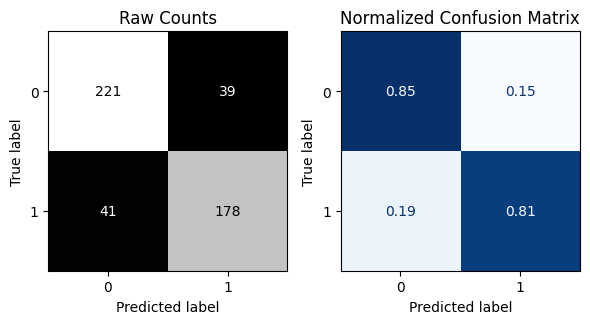


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       111
           1       0.59      0.71      0.65        49

    accuracy                           0.76       160
   macro avg       0.73      0.75      0.73       160
weighted avg       0.78      0.76      0.77       160



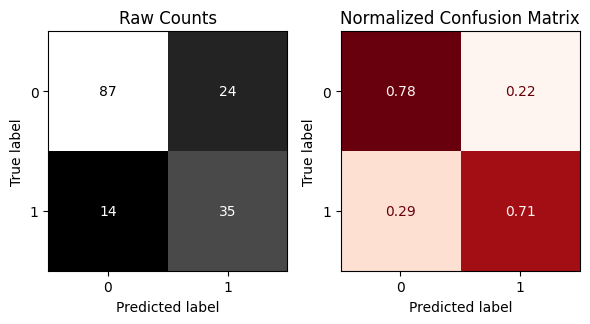

In [ ]:
#evaluate tunned model
evaluate_classification(g.best_estimator_,X_train,y_train,X_test,y_test)

the result of default RF model :accuracy 0.73 in testing data and .8 in training data
,in class 1 the value of  recall 0.73, percision .55 in testing data
FN false negative is 13

the tunned RF model accuracy is increase to 0.76 ,the recall .71 and precision 0.59  for testing data

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       260
           1       0.77      0.82      0.79       219

    accuracy                           0.80       479
   macro avg       0.80      0.80      0.80       479
weighted avg       0.81      0.80      0.80       479



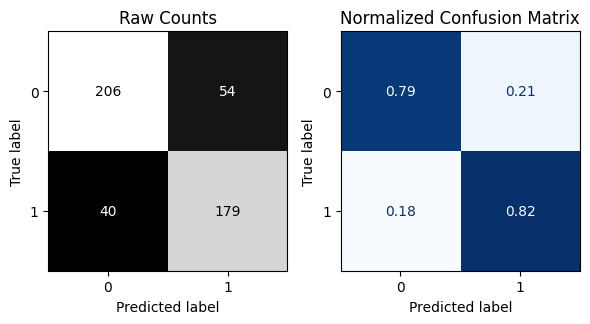


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       111
           1       0.48      0.67      0.56        49

    accuracy                           0.68       160
   macro avg       0.65      0.67      0.65       160
weighted avg       0.72      0.68      0.69       160



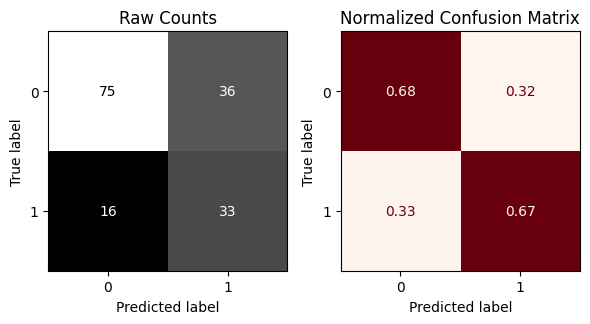

In [ ]:
#another classification model (KNN) default  k-nearest neighbour model
knn=KNeighborsClassifier()
knn_pip=make_pipeline(preprocessor,knn)
knn_pip.fit(X_train,y_train)
evaluate_classification(knn_pip,X_train,y_train,X_test,y_test)

In [ ]:
knn_pip.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('number',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='missing',
                                                                   strategy='constant')),
                                                    ('one...
                                                     OneHotEncoder(handle_unknown='ig

Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.77      0.80       260
           1       0.75      0.80      0.78       219

    accuracy                           0.79       479
   macro avg       0.79      0.79      0.79       479
weighted avg       0.79      0.79      0.79       479



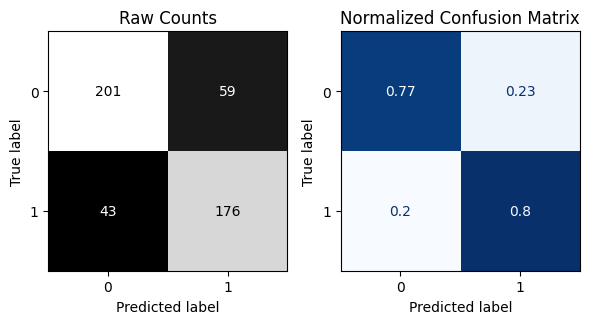


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       111
           1       0.52      0.71      0.60        49

    accuracy                           0.71       160
   macro avg       0.69      0.71      0.69       160
weighted avg       0.75      0.71      0.72       160



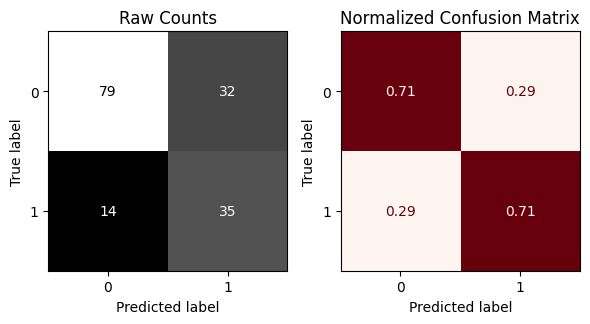

In [ ]:
#finging best K hyperparameter
n_list=list(range(1,33,2))
param = {
    "kneighborsclassifier__n_neighbors": n_list
}

grid = GridSearchCV(knn_pip, param, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
grid.best_params_
evaluate_classification(grid.best_estimator_,X_train,y_train,X_test,y_test)

the accuracy of default kNN model .68 in testing data ,.8 in training data
recall .67 precision .48

the tunned model achive .74 accuracy
with recall .71 in testing data

knn model is easier to used but the results is not good enough
I try to  used logistic regression with tunning c hyperparameter  with L1 and L2 Regularization

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       260
           1       0.76      0.74      0.75       219

    accuracy                           0.77       479
   macro avg       0.77      0.77      0.77       479
weighted avg       0.77      0.77      0.77       479



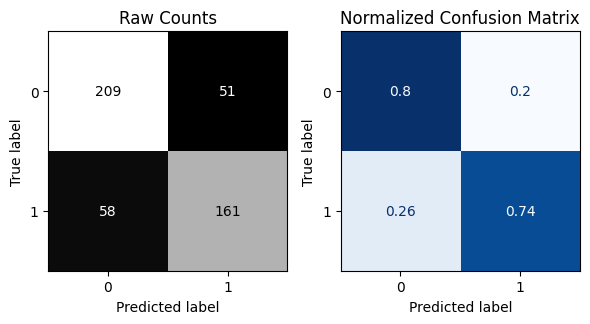


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.76      0.80       111
           1       0.56      0.71      0.63        49

    accuracy                           0.74       160
   macro avg       0.71      0.74      0.72       160
weighted avg       0.77      0.74      0.75       160



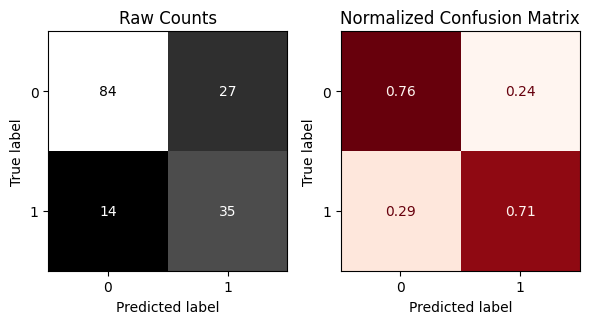

In [ ]:
#Logistic Regression model
logreg=LogisticRegression(random_state=42)
logreg_pip=make_pipeline(preprocessor,logreg)
logreg_pip.fit(X_train,y_train)
evaluate_classification(logreg_pip,X_train,y_train,X_test,y_test)

In [ ]:
#tunned- model
scale=StandardScaler()
logreg_pip=make_pipeline(preprocessor,LogisticRegression(random_state=42,max_iter=1000))
logreg_pip.get_params()

#define param
param_l1 = {
    "logisticregression__C": [.0001,.001,.01,.1,1,10.100,1000]
    ,"logisticregression__l1_ratio": [0,0.25,0.5,0.75,1]
    ,"logisticregression__penalty": ["l1"]
    ,"logisticregression__solver": ["liblinear"]
}

param_l2 = {
    "logisticregression__C": [.0001,.001,.01,.1,1,10,100,1000]
    ,"logisticregression__penalty": ["l2"]
    ,"logisticregression__solver": ["lbfgs","liblinear","sag","saga"]
}

param_elasticnet ={
    "logisticregression__l1_ratio": [0,0.25,0.5,0.75,1]
    ,"logisticregression__penalty": ["elasticnet"]
    ,"logisticregression__solver": ["saga"]
}
param = [param_l1,param_l2,param_elasticnet]
gs= GridSearchCV(logreg_pip,param,n_jobs=-1,verbose=1)
gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


{'logisticregression__C': 0.1,
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       260
           1       0.76      0.73      0.74       219

    accuracy                           0.77       479
   macro avg       0.77      0.76      0.77       479
weighted avg       0.77      0.77      0.77       479



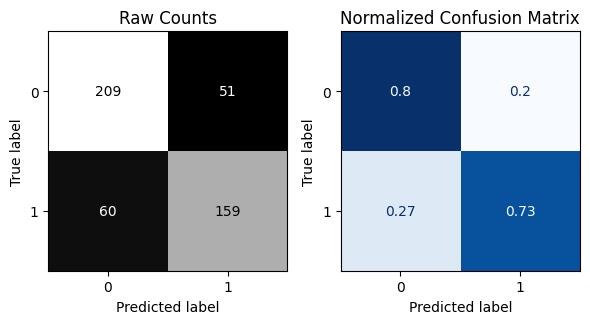


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.75      0.79       111
           1       0.55      0.69      0.61        49

    accuracy                           0.73       160
   macro avg       0.70      0.72      0.70       160
weighted avg       0.76      0.73      0.74       160



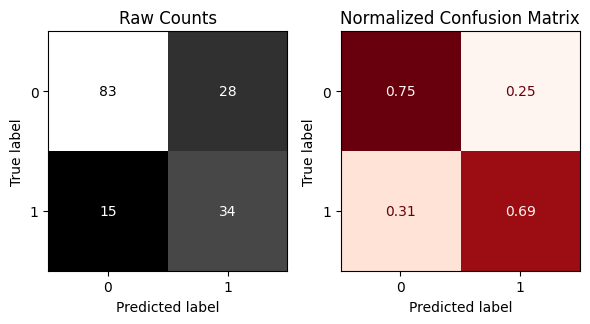

In [ ]:
evaluate_classification(gs.best_estimator_,X_train,y_train,X_test,y_test)

I choose tunned Random Forest with max-depth 5 ,min samples leaf 2 ,min sample split 10 , n-estimator 300
because higher accuracy ( the percentage of correct prediction from all prediction) is  .76

class 1
Precision: 0.59 Many predicted diabetics are actually false positives
Recall: 0.71  It detects 71% of real diabetic cases
F1-score: 0.65  Moderate performance

I use recall to compare with all models because know who patient has diabetes is very important (reduce FN)
